In [13]:
# Importing required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import joblib

In [14]:
# Loading the feature-engineered dataset
data = pd.read_csv("../data/model_ready_data.csv")
data.head()

,Country Name,year,temp_anomaly,lag_1,rolling_mean_5,decade,country_encoded
0,"Afghanistan, Islamic Rep. of",1971,0.652,0.898,0.775000,1970,0
1,"Afghanistan, Islamic Rep. of",1972,-1.089,0.652,0.153667,1970,0
2,"Afghanistan, Islamic Rep. of",1973,0.262,-1.089,0.180750,1970,0
3,"Afghanistan, Islamic Rep. of",1974,-0.470,0.262,0.050600,1970,0
4,"Afghanistan, Islamic Rep. of",1975,-0.468,-0.470,-0.222600,1970,0


In [15]:
# Redefining heatwave risk: comparing each year against its OWN recent trend (rolling_mean_5), not the full historical baseline
# This detects genuine short-term spikes, rather than just flagging "later years" due to the overall warming trend

data["deviation_from_recent"] = data["temp_anomaly"] - data["rolling_mean_5"]

# Using only training years to define what counts as a "significant" spike
train_deviation_std = data[data["year"] <= 2015]["deviation_from_recent"].std()

data["heatwave_risk"] = (data["deviation_from_recent"] > train_deviation_std).astype(int)

print(data["heatwave_risk"].value_counts())

heatwave_risk
0    9765
1    1812
Name: count, dtype: int64


In [16]:
features = ["year", "lag_1", "rolling_mean_5", "decade", "country_encoded"]
target = "heatwave_risk"

X = data[features]
y = data[target]

train_data = data[data["year"] <= 2015]
test_data = data[data["year"] > 2015]

X_train = train_data[features]
y_train = train_data[target]
X_test = test_data[features]
y_test = test_data[target]

print("Training set size:", len(X_train))
print("Test set size:", len(X_test))
print("High risk % in training set:", y_train.mean() * 100)
print("High risk % in test set:", y_test.mean() * 100)

Training set size: 10215
Test set size: 1362
High risk % in training set: 15.115026921194321
High risk % in test set: 19.676945668135097


In [17]:
# Scaling features so they're all on a similar range — helps the neural network train properly
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
# Building a small neural network for heatwave risk classification
model = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

c:\Users\RONIT\Desktop\Projects\Terra_Forecast\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241 (964.00 B)

 Trainable params: 241 (964.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Calculating class weights to handle the imbalance (high risk years are the minority class)
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)

{0: np.float64(0.5890324068734863), 1: np.float64(3.3079663212435233)}


In [20]:
# Training the neural network
history = model.fit(X_train_scaled, y_train,epochs=50,batch_size=32,validation_split=0.2,class_weight=class_weight_dict,verbose=1)

Epoch 1/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5410 - loss: 0.6995 - val_accuracy: 0.5056 - val_loss: 0.6938
Epoch 2/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5600 - loss: 0.6907 - val_accuracy: 0.5272 - val_loss: 0.6912
Epoch 3/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5778 - loss: 0.6845 - val_accuracy: 0.6084 - val_loss: 0.6761
Epoch 4/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5861 - loss: 0.6791 - val_accuracy: 0.5884 - val_loss: 0.6816
Epoch 5/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6089 - loss: 0.6751 - val_accuracy: 0.6143 - val_loss: 0.6751
Epoch 6/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6045 - loss: 0.6731 - val_accuracy: 0.6554 - val_loss: 0.6651
Epoch 7/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6151 - loss: 0.6701 - val_accuracy: 0.5942 - val_loss: 0.6813
Epoch 8/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6077 - loss: 0.6683 - val_accuracy: 0.

In [21]:
# Making predictions on the test set
y_pred_probs = model.predict(X_test_scaled)
y_pred = (y_pred_probs > 0.5).astype(int)

# Checking overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

# Checking precision/recall — more meaningful than accuracy alone, given the class imbalance
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test Accuracy: 0.40748898678414097

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.32      0.47      1094
           1       0.21      0.75      0.33       268

    accuracy                           0.41      1362
   macro avg       0.53      0.54      0.40      1362
weighted avg       0.72      0.41      0.44      1362



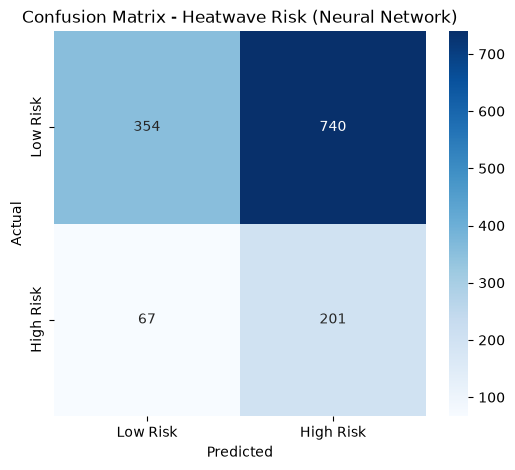

In [22]:
# Visualizing prediction results with a confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
import seaborn as sns
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",xticklabels=["Low Risk", "High Risk"],yticklabels=["Low Risk", "High Risk"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Heatwave Risk (Neural Network)")
plt.show()

In [23]:
# Using a more moderate class weight instead of the fully automatic "balanced" calculation
# This softens how aggressively the model favors catching class 1, reducing excessive false alarms
class_weight_dict_moderate = {0: 1.0, 1: 3.0}

# Rebuilding a fresh model (retraining from scratch, not continuing the old one)
model = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict_moderate,
    verbose=1
)

Epoch 1/50


c:\Users\RONIT\Desktop\Projects\Terra_Forecast\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8215 - loss: 0.8582 - val_accuracy: 0.8590 - val_loss: 0.4868
Epoch 2/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8464 - loss: 0.8384 - val_accuracy: 0.8590 - val_loss: 0.4947
Epoch 3/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8461 - loss: 0.8302 - val_accuracy: 0.8590 - val_loss: 0.4866
Epoch 4/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8453 - loss: 0.8226 - val_accuracy: 0.8590 - val_loss: 0.4416
Epoch 5/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8441 - loss: 0.8185 - val_accuracy: 0.8595 - val_loss: 0.4502
Epoch 6/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8371 - loss: 0.8127 - val_accuracy: 0.8600 - val_loss: 0.4515
Epoch 7/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8266 - loss: 0.8081 - val_accuracy: 0.8625 - val_loss: 0.4388
Epoch 8/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8243 - loss: 0.8060 - val_accuracy: 0.8561 - val_

In [24]:
# Evaluating the retrained model with moderate class weights
y_pred_probs = model.predict(X_test_scaled)
y_pred = (y_pred_probs > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Test Accuracy: 0.6387665198237885

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.69      0.75      1094
           1       0.25      0.43      0.32       268

    accuracy                           0.64      1362
   macro avg       0.54      0.56      0.54      1362
weighted avg       0.72      0.64      0.67      1362



In [25]:
# Trying a middle-ground class weight between the two previous attempts
class_weight_dict_v3 = {0: 1.0, 1: 2.0}

model = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict_v3,
    verbose=1
)

Epoch 1/50


c:\Users\RONIT\Desktop\Projects\Terra_Forecast\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8169 - loss: 0.6998 - val_accuracy: 0.8590 - val_loss: 0.4586
Epoch 2/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8463 - loss: 0.6672 - val_accuracy: 0.8590 - val_loss: 0.4451
Epoch 3/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8463 - loss: 0.6603 - val_accuracy: 0.8590 - val_loss: 0.4365
Epoch 4/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8462 - loss: 0.6560 - val_accuracy: 0.8590 - val_loss: 0.4417
Epoch 5/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8459 - loss: 0.6528 - val_accuracy: 0.8605 - val_loss: 0.4327
Epoch 6/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8453 - loss: 0.6504 - val_accuracy: 0.8605 - val_loss: 0.4282
Epoch 7/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8446 - loss: 0.6476 - val_accuracy: 0.8595 - val_loss: 0.4343
Epoch 8/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8448 - loss: 0.6452 - val_accuracy: 0.8595 - val_

In [26]:
# Evaluating the middle-ground version
y_pred_probs = model.predict(X_test_scaled)
y_pred = (y_pred_probs > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Test Accuracy: 0.8069016152716594

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1094
           1       0.54      0.14      0.22       268

    accuracy                           0.81      1362
   macro avg       0.68      0.55      0.55      1362
weighted avg       0.77      0.81      0.76      1362



In [27]:
# One more attempt — a weight between attempt 1 (balanced ≈5.67) and attempt 2 (3), aiming for a better trade-off
class_weight_dict_v4 = {0: 1.0, 1: 4.5}

model = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict_v4,
    verbose=1
)

Epoch 1/50


c:\Users\RONIT\Desktop\Projects\Terra_Forecast\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6971 - loss: 1.0594 - val_accuracy: 0.7930 - val_loss: 0.6141
Epoch 2/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7381 - loss: 1.0424 - val_accuracy: 0.8576 - val_loss: 0.5738
Epoch 3/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7731 - loss: 1.0338 - val_accuracy: 0.8267 - val_loss: 0.5950
Epoch 4/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7489 - loss: 1.0276 - val_accuracy: 0.8585 - val_loss: 0.5486
Epoch 5/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7620 - loss: 1.0212 - val_accuracy: 0.8253 - val_loss: 0.5828
Epoch 6/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7558 - loss: 1.0164 - val_accuracy: 0.8326 - val_loss: 0.5593
Epoch 7/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7505 - loss: 1.0102 - val_accuracy: 0.8179 - val_loss: 0.5685
Epoch 8/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7397 - loss: 1.0071 - val_accuracy: 0.8125 - val_

In [28]:
# Evaluating this attempt
y_pred_probs = model.predict(X_test_scaled)
y_pred = (y_pred_probs > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Test Accuracy: 0.5447870778267254

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.55      0.66      1094
           1       0.22      0.53      0.32       268

    accuracy                           0.54      1362
   macro avg       0.53      0.54      0.49      1362
weighted avg       0.71      0.54      0.59      1362



In [29]:
# Retraining the final chosen version — balanced class weights, prioritizing catching real heatwave risk
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

model = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/50


c:\Users\RONIT\Desktop\Projects\Terra_Forecast\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4728 - loss: 0.6988 - val_accuracy: 0.7670 - val_loss: 0.6509
Epoch 2/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4808 - loss: 0.6914 - val_accuracy: 0.8125 - val_loss: 0.6262
Epoch 3/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5781 - loss: 0.6848 - val_accuracy: 0.7298 - val_loss: 0.6368
Epoch 4/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6200 - loss: 0.6790 - val_accuracy: 0.6461 - val_loss: 0.6591
Epoch 5/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5983 - loss: 0.6755 - val_accuracy: 0.5585 - val_loss: 0.6848
Epoch 6/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6005 - loss: 0.6715 - val_accuracy: 0.7181 - val_loss: 0.6310
Epoch 7/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6191 - loss: 0.6694 - val_accuracy: 0.6344 - val_loss: 0.6624
Epoch 8/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5906 - loss: 0.6663 - val_accuracy: 0.8106 - val_

In [30]:
# Confirming this matches the original Attempt 1 result
y_pred_probs = model.predict(X_test_scaled)
y_pred = (y_pred_probs > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Test Accuracy: 0.6820851688693098

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.77      0.79      1094
           1       0.26      0.34      0.29       268

    accuracy                           0.68      1362
   macro avg       0.54      0.55      0.54      1362
weighted avg       0.71      0.68      0.70      1362



In [31]:
# Double-checking the class weights are actually the balanced version we intended
print(class_weight_dict)

{0: np.float64(0.5890324068734863), 1: np.float64(3.3079663212435233)}


In [32]:
# Setting a random seed so results are reproducible across runs
import tensorflow as tf
tf.random.set_seed(42)
np.random.seed(42)

In [36]:
# Setting a random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Training with balanced class weights (one final time)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

model = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    verbose=0
)

# Instead of the default 0.5 cutoff, lowering the threshold to catch more real risk cases
y_pred_probs = model.predict(X_test_scaled)
y_pred = (y_pred_probs > 0.4).astype(int)   # trying a middle threshold between 0.3 and 0.5

accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

c:\Users\RONIT\Desktop\Projects\Terra_Forecast\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test Accuracy: 0.32158590308370044

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.18      0.30      1094
           1       0.21      0.90      0.34       268

    accuracy                           0.32      1362
   macro avg       0.55      0.54      0.32      1362
weighted avg       0.75      0.32      0.31      1362



In [37]:
# Final chosen version: balanced class weights, threshold 0.4 — prioritizing catching real heatwave risk
# Trade-off note: this favors recall (catching real risks) over precision (avoiding false alarms),
# which is an appropriate choice for a warning system where missing a real risk is more costly than a false alert

model.save("../saved_models/heatwave_nn_model.keras")
joblib.dump(scaler, "../saved_models/heatwave_scaler.pkl")

# Saving the chosen threshold too, since the app must use this same 0.4 cutoff, not the default 0.5
import json
with open("../saved_models/heatwave_threshold.json", "w") as f:
    json.dump({"threshold": 0.4}, f)

print("Model, scaler, and threshold saved successfully.")

Model, scaler, and threshold saved successfully.
